## 1. Load and Analyze Dataset

In [1]:
# Install required visualization libraries
%pip install matplotlib seaborn

# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Install pyarrow
%pip install pyarrow

# Load the composite dataset
from parquet_files import COMPOSITE_DATA


df = pd.read_parquet(COMPOSITE_DATA, engine='pyarrow', use_nullable_dtypes=False)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique tickers: {df['ticker'].nunique()}")

df.head()

Note: you may need to restart the kernel to use updated packages.
Dataset shape: (39124, 23)
Date range: 2021-01-27 to 2021-08-15
Unique tickers: 300


,ticker,custom_sentiment,finbert_sentiment,date,on_volatile_date,adjacent_volatile_date,very_near_volatile_date,near_volatile_date,p-7,p-6,...,p-2,p-1,p+0,p+1,p+2,p+3,p+4,p+5,p+6,p+7
0,GME,-1.320963,-1.622274,2021-01-28,False,False,False,False,NaN,9.780000,...,36.994999,86.877502,48.400002,81.250000,56.25,22.500000,23.102501,13.375000,15.942500,15.000000
1,GME,-0.032856,0.572957,2021-01-28,False,False,False,False,NaN,9.780000,...,36.994999,86.877502,48.400002,81.250000,56.25,22.500000,23.102501,13.375000,15.942500,15.000000
2,GME,-0.462225,0.609483,2021-01-28,False,False,False,False,NaN,9.780000,...,36.994999,86.877502,48.400002,81.250000,56.25,22.500000,23.102501,13.375000,15.942500,15.000000
3,GME,-0.462225,0.514058,2021-01-28,False,False,False,False,NaN,9.780000,...,36.994999,86.877502,48.400002,81.250000,56.25,22.500000,23.102501,13.375000,15.942500,15.000000
4,AMC,-0.462225,0.514058,2021-01-28,False,False,False,False,NaN,29.700001,...,49.599998,199.000000,86.300003,132.600006,133.00,78.199997,89.699997,70.900002,68.300003,61.799999


In [3]:
# Analyze dataset structure
price_cols = [col for col in df.columns if col.startswith('p') and ('+' in col or '-' in col or col == 'p+0')]
volatile_cols = [col for col in df.columns if 'volatile' in col.lower()]

print(f"Price columns: {len(price_cols)}")
print(f"Volatile date indicators: {len(volatile_cols)}")
print(f"Most mentioned tickers:")
print(df['ticker'].value_counts().head(5))

df.sample(3)

Price columns: 15
Volatile date indicators: 4
Most mentioned tickers:
ticker
GME    12783
AMC     4545
DD      2699
NWS     1888
BB      1880
Name: count, dtype: int64


,ticker,custom_sentiment,finbert_sentiment,date,on_volatile_date,adjacent_volatile_date,very_near_volatile_date,near_volatile_date,p-7,p-6,...,p-2,p-1,p+0,p+1,p+2,p+3,p+4,p+5,p+6,p+7
12050,IT,0.825882,0.698736,2021-01-28,False,False,False,False,NaN,161.580002,...,157.089996,151.580002,157.190002,151.910004,154.009995,155.550003,159.449997,163.070007,164.500000,168.110001
33077,JPM,-0.462225,0.543011,2021-04-12,False,False,True,True,NaN,135.971695,...,138.027176,139.059341,138.765732,137.110626,134.548004,135.402206,136.407730,135.829315,132.821747,133.951828
29136,GME,0.396513,0.488135,2021-03-08,False,False,False,False,27.182501,25.434999,...,33.087502,34.435001,48.625000,61.724998,66.250000,65.000000,66.125000,55.035000,52.042500,52.452499


## 2. Data Cleaning and Preprocessing

In [4]:
# Create clean dataset
df_clean = df.copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Identify price columns
price_cols = [col for col in df_clean.columns if col.startswith('p') and ('+' in col or '-' in col or col == 'p+0')]
price_cols = sorted(price_cols, key=lambda x: int(x.replace('p', '').replace('+', '')))

# Clean data
valid_price_mask = df_clean[price_cols].notna().any(axis=1)
df_clean = df_clean[valid_price_mask].reset_index(drop=True)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Final dataset: {df_clean.shape[0]} rows, {len(price_cols)} price columns")

Final dataset: 38913 rows, 15 price columns


## 3. Exploratory Data Analysis

In [5]:
# Calculate price returns for regression targets
if 'p+0' in df_clean.columns and 'p+1' in df_clean.columns:
    valid_mask = df_clean['p+0'].notna() & df_clean['p+1'].notna()
    df_clean.loc[valid_mask, 'return_1d'] = (df_clean.loc[valid_mask, 'p+1'] / df_clean.loc[valid_mask, 'p+0']) - 1

if 'p+0' in df_clean.columns and 'p+3' in df_clean.columns:
    valid_mask = df_clean['p+0'].notna() & df_clean['p+3'].notna()
    df_clean.loc[valid_mask, 'return_3d'] = (df_clean.loc[valid_mask, 'p+3'] / df_clean.loc[valid_mask, 'p+0']) - 1

if 'p+0' in df_clean.columns and 'p+7' in df_clean.columns:
    valid_mask = df_clean['p+0'].notna() & df_clean['p+7'].notna()
    df_clean.loc[valid_mask, 'return_7d'] = (df_clean.loc[valid_mask, 'p+7'] / df_clean.loc[valid_mask, 'p+0']) - 1

# Analyze return distributions
for col in ['return_1d', 'return_3d', 'return_7d']:
    if col in df_clean.columns and df_clean[col].notna().sum() > 0:
        returns = df_clean[col].dropna()
        print(f"{col}: {len(returns)} samples, Mean: {returns.mean()*100:.2f}%, Std: {returns.std()*100:.2f}%")

return_1d: 38913 samples, Mean: 8.82%, Std: 27.43%
return_3d: 38913 samples, Mean: -11.03%, Std: 26.95%
return_7d: 32650 samples, Mean: -13.42%, Std: 41.56%


## 4. Feature Engineering

In [6]:
# price-based features
if 'p+0' in df_clean.columns and 'p-1' in df_clean.columns:
    df_clean['momentum_1d'] = (df_clean['p+0'] / df_clean['p-1']) - 1

if 'p+0' in df_clean.columns and 'p-3' in df_clean.columns:
    df_clean['momentum_3d'] = (df_clean['p+0'] / df_clean['p-3']) - 1

if 'p+0' in df_clean.columns and 'p-7' in df_clean.columns:
    df_clean['momentum_7d'] = (df_clean['p+0'] / df_clean['p-7']) - 1

# Price volatility
past_price_cols = [col for col in price_cols if '-' in col]
if len(past_price_cols) >= 3:
    past_prices = df_clean[past_price_cols].values
    df_clean['volatility'] = np.nanstd(past_prices, axis=1)

# Technical indicators
if 'p+0' in df_clean.columns:
    # Moving averages
    short_cols = ['p-2', 'p-1', 'p+0']
    long_cols = ['p-6', 'p-5', 'p-4', 'p-3', 'p-2', 'p-1', 'p+0']
    
    valid_short = df_clean[short_cols].notna().all(axis=1)
    valid_long = df_clean[long_cols].notna().all(axis=1)
    
    df_clean.loc[valid_short, 'sma_3d'] = df_clean.loc[valid_short, short_cols].mean(axis=1)
    df_clean.loc[valid_long, 'sma_7d'] = df_clean.loc[valid_long, long_cols].mean(axis=1)
    
    # MA crossover signal
    valid_ma = df_clean['sma_3d'].notna() & df_clean['sma_7d'].notna()
    df_clean.loc[valid_ma, 'ma_signal'] = (df_clean.loc[valid_ma, 'sma_3d'] > df_clean.loc[valid_ma, 'sma_7d']).astype(int)

# Time features
if 'date' in df_clean.columns:
    df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
    df_clean['is_monday'] = (df_clean['day_of_week'] == 0).astype(int)
    df_clean['is_friday'] = (df_clean['day_of_week'] == 4).astype(int)

# Volatile date features are already in the new data
volatile_cols = [col for col in df_clean.columns if 'volatile' in col.lower()]



## 5. Model Building and Training

In [ ]:
# Deep Learning for Time Series
%pip install xgboost tensorflow keras scikit-learn

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Select price-only features
feature_candidates = [
    'momentum_1d', 'momentum_3d', 'momentum_7d', 'volatility',
    'sma_3d', 'sma_7d', 'ma_signal', 'day_of_week',
    'is_monday', 'is_friday'
]

# Add volatile date indicators
volatile_cols = [col for col in df_clean.columns if 'volatile' in col.lower()]
feature_candidates.extend(volatile_cols)

# Filter to existing columns
available_features = [col for col in feature_candidates if col in df_clean.columns]

# Prepare dataset for 1-day return prediction
target_col = 'return_1d'
modeling_data = df_clean[available_features + [target_col, 'date', 'ticker']].copy()

# Remove missing targets
modeling_data = modeling_data.dropna(subset=[target_col])

# Remove incomplete rows
missing_threshold = len(available_features) * 0.5
feature_completeness = modeling_data[available_features].notna().sum(axis=1)
complete_data = modeling_data[feature_completeness >= missing_threshold].copy()

complete_data = complete_data.sort_values('date').reset_index(drop=True)

# Fill missing values
X = complete_data[available_features].fillna(complete_data[available_features].median())
y = complete_data[target_col]

# Time-based split
split_idx = int(0.8 * len(complete_data))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
# prepare datasets for multiple horizons (horizons = ['1d', '3d', '7d']))
modeling_datasets = {}

for target_col in ['return_1d', 'return_3d', 'return_7d']:
    if target_col in df_clean.columns:
        horizon = target_col.replace('return_', '')
        modeling_data = df_clean[available_features + [target_col, 'date', 'ticker']].copy()
        modeling_data = modeling_data.dropna(subset=[target_col])
        
        feature_completeness = modeling_data[available_features].notna().sum(axis=1)
        complete_data = modeling_data[feature_completeness >= missing_threshold].copy()
        
        X = complete_data[available_features].fillna(complete_data[available_features].median())
        y = complete_data[target_col]
        
        split_idx = int(0.8 * len(complete_data))
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
        
        modeling_datasets[horizon] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test
        }

# Train models for all prediction horizons
all_results = {}
best_models = {}

for horizon in modeling_datasets.keys():
    
    # Get data for this horizon
    X_train = modeling_datasets[horizon]['X_train']
    X_test = modeling_datasets[horizon]['X_test']
    y_train = modeling_datasets[horizon]['y_train']
    y_test = modeling_datasets[horizon]['y_test']
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    horizon_results = {}
    horizon_models = {}
    
    # 1. Baseline
    baseline_pred = np.full(len(y_test), y_train.mean())
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_r2 = 0.0
    horizon_results['Baseline'] = {'MAE': baseline_mae, 'R²': baseline_r2}
    horizon_models['Baseline'] = (None, None, baseline_pred)
    
    # 2. Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    lr_pred = lr_model.predict(X_test_scaled)
    lr_mae = mean_absolute_error(y_test, lr_pred)
    lr_r2 = r2_score(y_test, lr_pred)
    horizon_results['Linear'] = {'MAE': lr_mae, 'R²': lr_r2}
    horizon_models['Linear'] = (lr_model, scaler, lr_pred)
    
    # 3. Ridge Regression
    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_pred = ridge_model.predict(X_test_scaled)
    ridge_mae = mean_absolute_error(y_test, ridge_pred)
    ridge_r2 = r2_score(y_test, ridge_pred)
    horizon_results['Ridge'] = {'MAE': ridge_mae, 'R²': ridge_r2}
    horizon_models['Ridge'] = (ridge_model, scaler, ridge_pred)
    
    # 4. Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    horizon_results['Random Forest'] = {'MAE': rf_mae, 'R²': rf_r2}
    horizon_models['Random Forest'] = (rf_model, None, rf_pred)
    
    # Find best model for this horizon
    best_model_name = max(horizon_results.keys(), key=lambda k: horizon_results[k]['R²'])
    
    all_results[horizon] = horizon_results
    best_models[horizon] = {
        'name': best_model_name,
        'model': horizon_models[best_model_name],
        'metrics': horizon_results[best_model_name],
        'y_test': y_test
    }

# Deep Learning Models
print("\nDeep Learning Models:")

# Set random seeds for reproducibility
np.random.seed(42)

def create_sequences(data, target, lookback_window=10):
    """
    Create sequences for LSTM input
    lookback_window: number of previous time steps to use as input
    """
    X_sequences, y_sequences = [], []
    
    for i in range(lookback_window, len(data)):
        # 'lookback_window' time steps as features
        X_sequences.append(data[i-lookback_window:i])
        y_sequences.append(target[i])
    
    return np.array(X_sequences), np.array(y_sequences)

# Deep Learning imports
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def create_advanced_lstm_model(input_shape, horizon_name):
    """
    Create LSTM model
    """
    inputs = keras.Input(shape=input_shape)
    
    # Multi-layer LSTM with dropout for regularization
    x = layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)(x)
    
    # Dense layers with regularization
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    # Output layer
    outputs = layers.Dense(1, activation='linear')(x)
    
    model = Model(inputs, outputs, name=f'LSTM_{horizon_name}')
    
    # Compile with advanced optimizer
    model.compile(
        optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def create_cnn_lstm_hybrid(input_shape, horizon_name):
    """
    Create hybrid CNN-LSTM model for pattern detection + sequence modeling
    """
    inputs = keras.Input(shape=input_shape)
    
    # CNN layers
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    # LSTM layers
    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(x)
    x = layers.LSTM(32, dropout=0.2)(x)
    
    # Dense layers
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    
    model = Model(inputs, outputs, name=f'CNN_LSTM_{horizon_name}')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Deep Learning Results Storage
deep_learning_results = {}

# Train deep learning models for each horizon
for horizon in modeling_datasets.keys():
    print(f"\nProcessing {horizon} horizon")

    # Get data
    X_train = modeling_datasets[horizon]['X_train']
    X_test = modeling_datasets[horizon]['X_test']
    y_train = modeling_datasets[horizon]['y_train']
    y_test = modeling_datasets[horizon]['y_test']
    
    # Scale data for neural networks
    # normalized inputs work better
    feature_scaler = MinMaxScaler(feature_range=(-1, 1))
    target_scaler = MinMaxScaler(feature_range=(-1, 1))
    
    X_train_scaled = feature_scaler.fit_transform(X_train)
    X_test_scaled = feature_scaler.transform(X_test)
    
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()
    
    # Create sequences for LSTM (use last 10 time steps to predict next)
    lookback = 10
    
    if len(X_train_scaled) > lookback * 2:  # Ensure sufficient data
        
        # Create sequences
        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, lookback)
        X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, lookback)

        val_split = int(0.8 * len(X_train_seq))
        X_val_seq = X_train_seq[val_split:]
        y_val_seq = y_train_seq[val_split:]
        X_train_seq = X_train_seq[:val_split]
        y_train_seq = y_train_seq[:val_split]
        
        # Define callbacks
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=15, 
            restore_best_weights=True,
            verbose=1
        )
        
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=8,
            min_lr=1e-7,
            verbose=1
        )
        
        model_checkpoint = ModelCheckpoint(
            f'best_model_{horizon}.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
        
        callbacks_list = [early_stopping, reduce_lr, model_checkpoint]
        
        # Model 1: Advanced LSTM
        print(f"  Training LSTM Model...")
        lstm_model = create_advanced_lstm_model((lookback, X_train.shape[1]), horizon)

        lstm_history = lstm_model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100,
            batch_size=32,
            callbacks=callbacks_list,
            verbose=0
        )
        
        # Make predictions
        lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)
        lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
        y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        lstm_r2 = r2_score(y_test_actual, lstm_pred)
        lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
        
        print(f"    LSTM Results: R²={lstm_r2:.4f}, MAE={lstm_mae*100:.3f}%")

        # Model 2: CNN-LSTM Hybrid
        print(f"  Training CNN-LSTM Hybrid...")
        cnn_lstm_model = create_cnn_lstm_hybrid((lookback, X_train.shape[1]), horizon)

        cnn_lstm_history = cnn_lstm_model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100,
            batch_size=32,
            callbacks=callbacks_list,
            verbose=0
        )
        
        # Make predictions
        cnn_lstm_pred_scaled = cnn_lstm_model.predict(X_test_seq, verbose=0)
        cnn_lstm_pred = target_scaler.inverse_transform(cnn_lstm_pred_scaled.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        cnn_lstm_r2 = r2_score(y_test_actual, cnn_lstm_pred)
        cnn_lstm_mae = mean_absolute_error(y_test_actual, cnn_lstm_pred)
        
        print(f"    CNN-LSTM Results: R²={cnn_lstm_r2:.4f}, MAE={cnn_lstm_mae*100:.3f}%")

        deep_learning_results[horizon] = {
            'LSTM': {
                'model': lstm_model,
                'r2': lstm_r2,
                'mae': lstm_mae,
                'predictions': lstm_pred,
                'history': lstm_history
            },
            'CNN_LSTM': {
                'model': cnn_lstm_model,
                'r2': cnn_lstm_r2,
                'mae': cnn_lstm_mae,
                'predictions': cnn_lstm_pred,
                'history': cnn_lstm_history
            },
            'actual': y_test_actual,
            'scalers': {
                'feature_scaler': feature_scaler,
                'target_scaler': target_scaler
            }
        }
        
        # Update best models if deep learning performs better
        best_dl_r2 = max(lstm_r2, cnn_lstm_r2)
        best_dl_name = 'LSTM' if lstm_r2 > cnn_lstm_r2 else 'CNN_LSTM'
        # Compare with traditional models
        traditional_best_r2 = best_models[horizon]['metrics']['R²']
        
        if best_dl_r2 > traditional_best_r2:
            best_models[horizon] = {
                'name': best_dl_name,
                'model': deep_learning_results[horizon][best_dl_name]['model'],
                'metrics': {'R²': best_dl_r2, 'MAE': deep_learning_results[horizon][best_dl_name]['mae']},
                'y_test': y_test_actual
            }

    else:
        print(f"  Insufficient data for sequence modeling")

# Print performance summary for all horizons
print(f"\nPerformance Summary Across All Models:")
for horizon in all_results.keys():
    # Get traditional best model metrics
    traditional_best = best_models[horizon]['name']
    traditional_r2 = best_models[horizon]['metrics']['R²']
    traditional_mae = best_models[horizon]['metrics']['MAE']
    
    print(f"\n{horizon} Predictions:")
    print(f"  Traditional Best: {traditional_best} - R²={traditional_r2:.4f}, MAE={traditional_mae*100:.3f}%")
    
    if horizon in deep_learning_results:
        lstm_r2 = deep_learning_results[horizon]['LSTM']['r2']
        lstm_mae = deep_learning_results[horizon]['LSTM']['mae']
        cnn_lstm_r2 = deep_learning_results[horizon]['CNN_LSTM']['r2']
        cnn_lstm_mae = deep_learning_results[horizon]['CNN_LSTM']['mae']
        
        print(f"  LSTM Model:       R²={lstm_r2:.4f}, MAE={lstm_mae*100:.3f}%")
        print(f"  CNN-LSTM Hybrid:  R²={cnn_lstm_r2:.4f}, MAE={cnn_lstm_mae*100:.3f}%")
        
        # Determine overall winner
        all_r2s = [traditional_r2, lstm_r2, cnn_lstm_r2]
        best_overall_r2 = max(all_r2s)
        
        if best_overall_r2 == lstm_r2:
            print(f"  Best Overall: LSTM (Deep Learning)")
        elif best_overall_r2 == cnn_lstm_r2:
            print(f"  Best Overall: CNN-LSTM Hybrid (Deep Learning)")
        else:
            print(f"  Best Overall: {traditional_best} (Traditional)")

## 6. Multi-Day Model Evaluation and Analysis

In [ ]:
print("Analysis by Prediction Horizon (number of days past t)")

for horizon in best_models.keys():
    print(f"\n{horizon.upper()} PREDICTIONS:")
    
    model_name = best_models[horizon]['name']
    metrics = best_models[horizon]['metrics']
    y_test = best_models[horizon]['y_test']
    
    print(f"  Best model: {model_name}")
    print(f"  R²: {metrics['R²']:.4f}")
    print(f"  MAE: {metrics['MAE']*100:.3f}%")
    
    # Handle different model types
    if model_name in ['LSTM', 'CNN_LSTM']:
        # Deep learning model - no traditional feature importance
        print(f"  Deep Learning model")
        
        # Show training history if available
        if horizon in deep_learning_results and model_name in deep_learning_results[horizon]:
            history = deep_learning_results[horizon][model_name]['history']
            final_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            print(f"  Final training loss: {final_loss:.6f}")
            print(f"  Final validation loss: {final_val_loss:.6f}")
            
    else:
        # Traditional ML model
        model_tuple = best_models[horizon]['model']
        if isinstance(model_tuple, tuple) and len(model_tuple) == 3:
            model_obj, scaler, predictions = model_tuple
            
            # Feature importance analysis
            if hasattr(model_obj, 'feature_importances_'):
                # Random Forest
                feature_importance = pd.DataFrame({
                    'feature': available_features,
                    'importance': model_obj.feature_importances_
                }).sort_values('importance', ascending=False)
                print(f"  Top 3 features:")
                for i, (_, row) in enumerate(feature_importance.head(3).iterrows()):
                    print(f"    {i+1}. {row['feature']}: {row['importance']:.4f}")
            elif hasattr(model_obj, 'coef_'):
                # Linear/Ridge
                feature_importance = pd.DataFrame({
                    'feature': available_features,
                    'coefficient': np.abs(model_obj.coef_)
                }).sort_values('coefficient', ascending=False)
                print(f"  Top 3 features:")
                for i, (_, row) in enumerate(feature_importance.head(3).iterrows()):
                    print(f"    {i+1}. {row['feature']}: {row['coefficient']:.4f}")
    
    # Prediction quality analysis
    if metrics['R²'] > 0:
        # Get predictions based on model type
        if model_name in ['LSTM', 'CNN_LSTM'] and horizon in deep_learning_results:
            predictions = deep_learning_results[horizon][model_name]['predictions']
            y_test_actual = deep_learning_results[horizon]['actual']
            correlation = np.corrcoef(y_test_actual, predictions)[0,1]
        else:
            model_tuple = best_models[horizon]['model']
            if isinstance(model_tuple, tuple) and len(model_tuple) == 3:
                _, _, predictions = model_tuple
                correlation = np.corrcoef(y_test, predictions)[0,1]
            else:
                correlation = 0.0
        print(f"  Prediction correlation: {correlation:.4f}")

Analysis by Prediction Horizon (number of days past t)

1D PREDICTIONS:
  Best model: Random Forest
  R²: 0.2101
  MAE: 2.964%
  Top 3 features:
    1. momentum_1d: 0.7693
    2. momentum_7d: 0.0793
    3. momentum_3d: 0.0580
  Prediction correlation: 0.4906

3D PREDICTIONS:
  Best model: Baseline
  R²: 0.0000
  MAE: 15.739%

7D PREDICTIONS:
  Best model: Baseline
  R²: 0.0000
  MAE: 18.164%


In [ ]:
print("\nMulti-Day Analysis and Conclusions:")
print("Prediction difficulty increases with horizon (number of days past t):")

for horizon in ['1d', '3d', '7d']:
    if horizon in best_models:
        r2 = best_models[horizon]['metrics']['R²']
        mae = best_models[horizon]['metrics']['MAE']
        model_name = best_models[horizon]['name']
        print(f"{horizon}: {model_name} - R²={r2:.4f}, MAE={mae*100:.3f}%")

# Find best overall horizon
best_overall_horizon = max(best_models.keys(), key=lambda h: best_models[h]['metrics']['R²'])
best_r2 = best_models[best_overall_horizon]['metrics']['R²']

print(f"\nBest predictive horizon: {best_overall_horizon} (R²={best_r2:.4f})")

if best_overall_horizon == '1d':
    print("Short-term price movements are most predictable")
elif best_overall_horizon == '7d':
    print("Longer-term trends are more predictable than daily noise")
else:
    print("Medium-term (3-day) predictions work best")



Multi-Day Analysis and Conclusions:
Prediction difficulty increases with horizon (number of days past t):
1d: Random Forest - R²=0.2101, MAE=2.964%
3d: Baseline - R²=0.0000, MAE=15.739%
7d: Baseline - R²=0.0000, MAE=18.164%

Best predictive horizon: 1d (R²=0.2101)
Short-term price movements are most predictable


## 7. Model Performance Summary


In [ ]:
# Model Performance Summary
results_summary = {}

for horizon in all_results.keys():
    traditional_best = best_models[horizon]['name']
    traditional_r2 = best_models[horizon]['metrics']['R²']
    
    summary = {
        'traditional': {'name': traditional_best, 'r2': traditional_r2}
    }
    
    if horizon in deep_learning_results:
        lstm_r2 = deep_learning_results[horizon]['LSTM']['r2']
        cnn_lstm_r2 = deep_learning_results[horizon]['CNN_LSTM']['r2']
        
        summary['lstm'] = {'r2': lstm_r2}
        summary['cnn_lstm'] = {'r2': cnn_lstm_r2}
        
        # Determine best model
        all_scores = {'Traditional': traditional_r2, 'LSTM': lstm_r2, 'CNN-LSTM': cnn_lstm_r2}
        winner = max(all_scores, key=all_scores.get)
        summary['winner'] = {'name': winner, 'r2': all_scores[winner]}
    else:
        summary['winner'] = {'name': traditional_best, 'r2': traditional_r2}
    
    results_summary[horizon] = summary

# Print concise results
for horizon, summary in results_summary.items():
    print(f"{horizon.upper()}: {summary['winner']['name']} (R² = {summary['winner']['r2']:.3f})")

1D: Traditional (R² = 0.210)
3D: Traditional (R² = 0.000)
7D: Traditional (R² = 0.000)


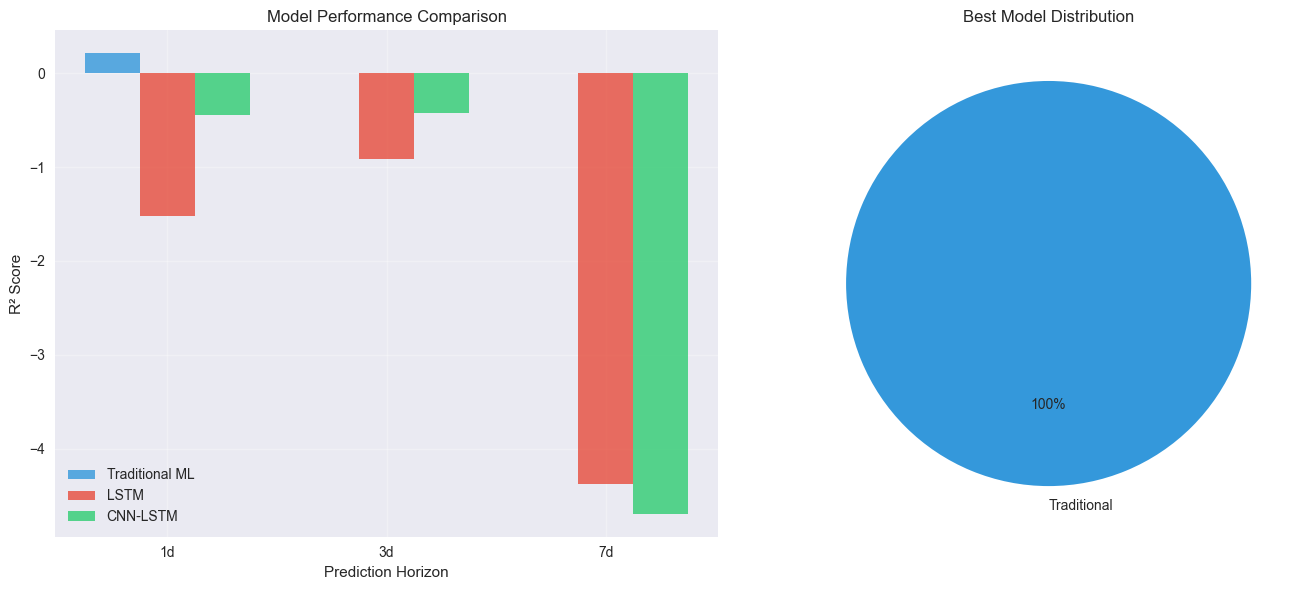

In [ ]:
# Model Performance Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data
horizons = list(results_summary.keys())
traditional_scores = [results_summary[h]['traditional']['r2'] for h in horizons]
lstm_scores = [results_summary[h].get('lstm', {}).get('r2', 0) for h in horizons]
cnn_lstm_scores = [results_summary[h].get('cnn_lstm', {}).get('r2', 0) for h in horizons]

# R² Comparison
x = np.arange(len(horizons))
width = 0.25

ax1.bar(x - width, traditional_scores, width, label='Traditional ML', color='#3498db', alpha=0.8)
ax1.bar(x, lstm_scores, width, label='LSTM', color='#e74c3c', alpha=0.8)
ax1.bar(x + width, cnn_lstm_scores, width, label='CNN-LSTM', color='#2ecc71', alpha=0.8)

ax1.set_xlabel('Prediction Horizon')
ax1.set_ylabel('R² Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(horizons)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Winner summary
winners = [results_summary[h]['winner']['name'] for h in horizons]
winner_counts = pd.Series(winners).value_counts()

colors = {'Traditional': '#3498db', 'LSTM': '#e74c3c', 'CNN-LSTM': '#2ecc71'}
pie_colors = [colors.get(model, '#95a5a6') for model in winner_counts.index]

ax2.pie(winner_counts.values, labels=winner_counts.index, autopct='%1.0f%%', 
        colors=pie_colors, startangle=90)
ax2.set_title('Best Model Distribution')

plt.tight_layout()
plt.show()

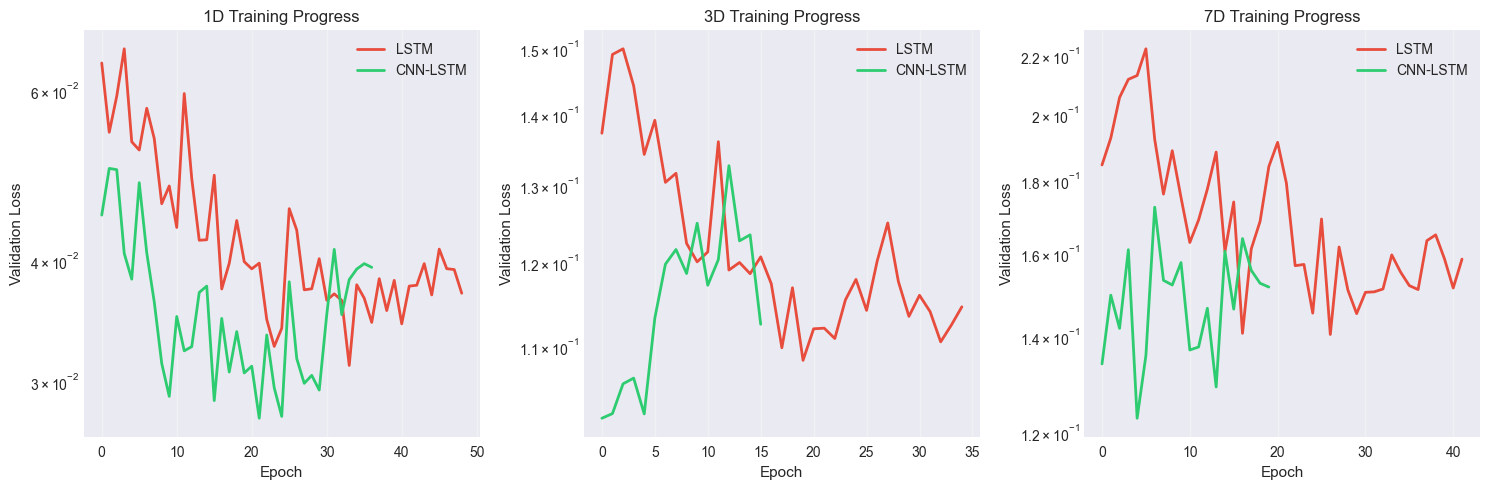

In [ ]:
# Deep Learning Training Analysis
if deep_learning_results:
    fig, axes = plt.subplots(1, len(deep_learning_results), figsize=(5*len(deep_learning_results), 5))
    if len(deep_learning_results) == 1:
        axes = [axes]
    
    for idx, (horizon, results) in enumerate(deep_learning_results.items()):
        lstm_history = results['LSTM']['history']
        cnn_lstm_history = results['CNN_LSTM']['history']
        
        # Plot validation loss only (most important for model evaluation)
        axes[idx].plot(lstm_history.history['val_loss'], label='LSTM', color='#e74c3c', linewidth=2)
        axes[idx].plot(cnn_lstm_history.history['val_loss'], label='CNN-LSTM', color='#2ecc71', linewidth=2)
        
        axes[idx].set_title(f'{horizon.upper()} Training Progress')
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel('Validation Loss')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_yscale('log')
        
    plt.tight_layout()
    plt.show()

Deep Learning Model Performance:

1D Horizon:
  LSTM R²: -1.5242
  CNN-LSTM R²: -0.4427
  Overall Winner: Traditional (R² = 0.2101)

3D Horizon:
  LSTM R²: -0.9161
  CNN-LSTM R²: -0.4246
  Overall Winner: Traditional (R² = 0.0000)

7D Horizon:
  LSTM R²: -4.3714
  CNN-LSTM R²: -4.6909
  Overall Winner: Traditional (R² = 0.0000)


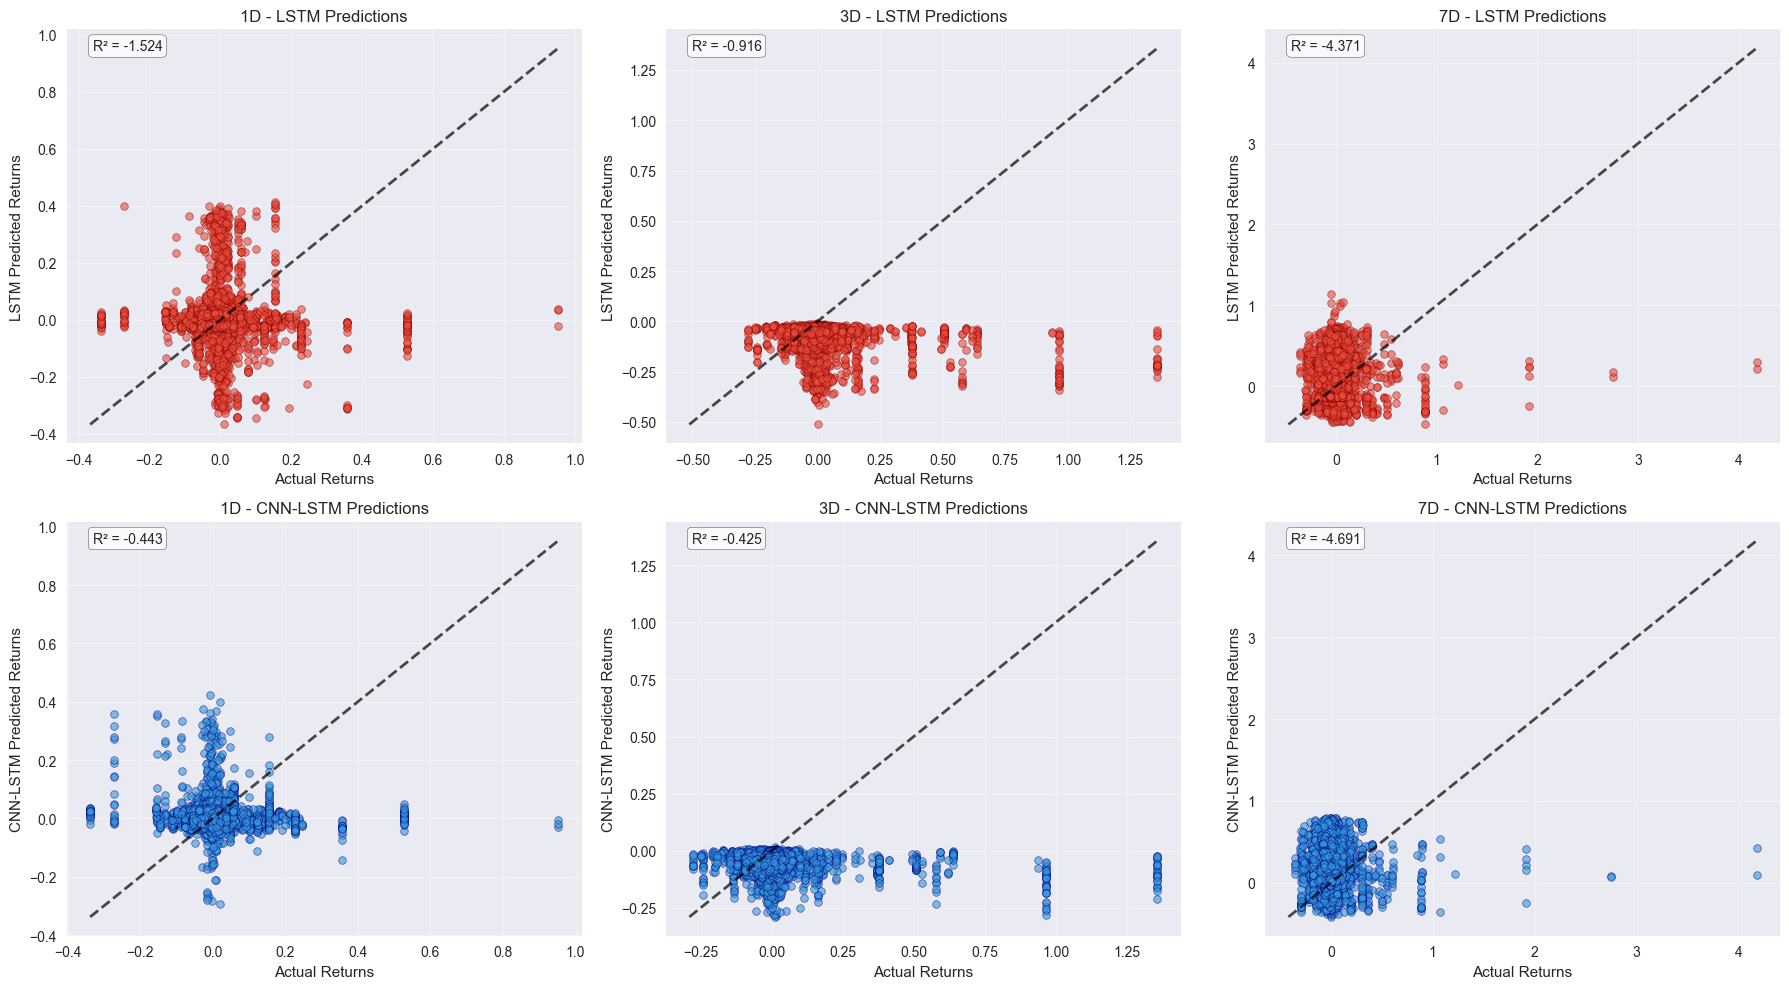

In [ ]:
# Prediction Accuracy Analysis - Deep Learning Models
if deep_learning_results:
    print("Deep Learning Model Performance:")
    
    fig, axes = plt.subplots(2, len(deep_learning_results), figsize=(6*len(deep_learning_results), 10))
    if len(deep_learning_results) == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (horizon, results) in enumerate(deep_learning_results.items()):
        actual = results['actual']
        
        # Plot LSTM results
        lstm_predictions = results['LSTM']['predictions']
        lstm_r2 = r2_score(actual, lstm_predictions)
        
        # LSTM subplot (top row)
        axes[0, idx].scatter(actual, lstm_predictions, alpha=0.6, s=30, color='#e74c3c', edgecolors='darkred', linewidth=0.5)
        
        # Perfect prediction line
        min_val = min(actual.min(), lstm_predictions.min())
        max_val = max(actual.max(), lstm_predictions.max())
        axes[0, idx].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='Perfect Prediction')
        
        axes[0, idx].set_xlabel('Actual Returns')
        axes[0, idx].set_ylabel('LSTM Predicted Returns')
        axes[0, idx].set_title(f'{horizon.upper()} - LSTM Predictions')
        axes[0, idx].grid(True, alpha=0.3)
        axes[0, idx].text(0.05, 0.95, f'R² = {lstm_r2:.3f}', transform=axes[0, idx].transAxes, 
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # CNN-LSTM subplot (bottom row)
        cnn_lstm_predictions = results['CNN_LSTM']['predictions']
        cnn_lstm_r2 = r2_score(actual, cnn_lstm_predictions)
        
        axes[1, idx].scatter(actual, cnn_lstm_predictions, alpha=0.6, s=30, color='#3498db', edgecolors='navy', linewidth=0.5)
        
        min_val = min(actual.min(), cnn_lstm_predictions.min())
        max_val = max(actual.max(), cnn_lstm_predictions.max())
        axes[1, idx].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='Perfect Prediction')
        
        axes[1, idx].set_xlabel('Actual Returns')
        axes[1, idx].set_ylabel('CNN-LSTM Predicted Returns')
        axes[1, idx].set_title(f'{horizon.upper()} - CNN-LSTM Predictions')
        axes[1, idx].grid(True, alpha=0.3)
        axes[1, idx].text(0.05, 0.95, f'R² = {cnn_lstm_r2:.3f}', transform=axes[1, idx].transAxes, 
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Print comparison
        overall_winner = results_summary[horizon]['winner']['name']
        overall_r2 = results_summary[horizon]['winner']['r2']
        
        print(f"\n{horizon.upper()} Horizon:")
        print(f"  LSTM R²: {lstm_r2:.4f}")
        print(f"  CNN-LSTM R²: {cnn_lstm_r2:.4f}")
        print(f"  Overall Winner: {overall_winner} (R² = {overall_r2:.4f})")
        
    plt.tight_layout()
    plt.show()